In [1]:
using Pkg 
Pkg.activate("..")

  Activating project at `~/code/PhasorNetworks.jl`


In [2]:
include("../src/PhasorNetworks.jl")
using .PhasorNetworks, Plots, DifferentialEquations

In [3]:
using Lux, MLUtils, MLDatasets, OneHotArrays, Statistics, Test, LuxCUDA
using Random: Xoshiro, AbstractRNG
using Base: @kwdef
using Zygote: withgradient
using Optimisers, ComponentArrays
using Statistics: mean
using LinearAlgebra: diag
using PhasorNetworks: bind
using Distributions: Normal
using DifferentialEquations: Heun, Tsit5

[ Info: Precompiling PhasorNetworks [c32d742c-e486-48f1-8804-9f6fb4d3f42c] (cache misses: include_dependency fsize change (2), mismatched flags (16))


# Static attention product

In [4]:
rng = Xoshiro(42)

Xoshiro(0xa379de7eeeb2a4e8, 0x953dccb6b532b3af, 0xf597b8ff8cfd652a, 0xccd7337c571680d1, 0xc90c4a0730db3f7e)

In [5]:
cdev = cpu_device()
gdev = gpu_device()

(::CUDADevice{Nothing}) (generic function with 1 method)

In [6]:
q = random_symbols((4, 64, 512), rng)
k = random_symbols((4, 32, 512), rng)
v = random_symbols((4, 32, 512), rng);

In [7]:
q, k, v = (q, k, v) .|> gdev

(Float32[-0.091034174 0.33917928 … 0.7826654 0.24790657; -0.65285087 -0.4828291 … -0.72534704 -0.89736307; 0.32237244 -0.7229662 … -0.54584837 -0.9041953; -0.35667682 -0.6671227 … -0.5309526 -0.61719847;;; 0.71608126 -0.45675933 … 0.467353 -0.09929335; -0.20839036 0.4270022 … -0.6866617 0.25354612; 0.49520743 0.9320961 … -0.58690906 -0.18206036; -0.16922593 -0.6162381 … -0.030122042 -0.86962867;;; -0.82497346 0.56005025 … 0.6548073 -0.1595478; -0.8821025 -0.64632916 … -0.25539947 -0.85281885; -0.9143027 0.7800586 … -0.19363868 0.70287323; 0.89194727 -0.21503568 … 0.33076096 -0.32862306;;; … ;;; -0.4953779 0.7469375 … 0.24980557 -0.00034451485; -0.04199195 0.0984118 … -0.8751414 0.27139044; 0.7955264 -0.92993736 … 0.32659996 -0.030631185; -0.47544432 -0.3583634 … -0.10030997 -0.30300975;;; -0.56644356 -0.9054899 … -0.7531769 -0.050798535; -0.11661649 0.68115926 … -0.121946454 -0.7811066; -0.06485784 0.031767726 … 0.15479612 -0.040259123; 0.11169076 0.19812703 … -0.07139909 0.8895699;;; 

In [8]:
import .PhasorNetworks: attend

In [9]:
scores = similarity_outer(q, k, dims=2) |> cdev;

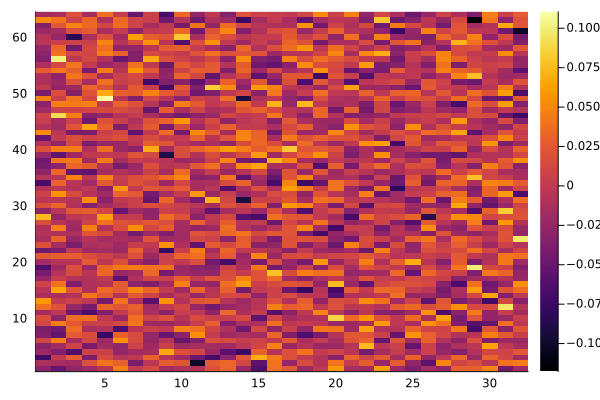

In [10]:
heatmap(scores[1,:,:])

In [11]:
size(scores)

(4, 64, 32)

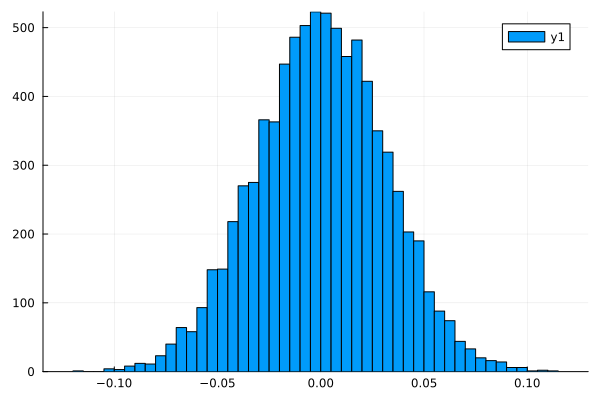

In [12]:
histogram(vec(scores))

In [13]:
function attend(q::AbstractArray{<:Real, 3}, k::AbstractArray{<:Real, 3}, v::AbstractArray{<:Real, 3})
    #compute qk scores
    #produces (b qt kt)
    scores = similarity_outer(q, k, dims=2)
    #do complex-domain matrix multiply of values by scores (b kt v)
    v = angle_to_complex(v)
    #multiply each value by the scores across batch
    #(b kt v) * (b qt kt) ... (v kt) * (kt qt) over b
    output = stack([scores[i,:,:] * v[i,:,:]  for i in axes(v, 1)], dims=1)
    output = complex_to_angle(output)
    return output
end

attend (generic function with 2 methods)

In [14]:
atv = attend(q, k, v) |> cdev

4×64×512 Array{Float32, 3}:
[:, :, 1] =
 -0.407561   -0.863585   0.0843273  …   0.191351   -0.118917  -0.178831
 -0.69719     0.925332  -0.864558       0.501647    0.414775   0.316622
 -0.986554    0.854746   0.715521      -0.0852525  -0.15666    0.890974
  0.0632857   0.625349   0.224653       0.912785   -0.525497   0.822177

[:, :, 2] =
 -0.162246   -0.910596   0.758035  …   0.570292   0.715149  -0.538377
 -0.782154   -0.189712  -0.371492     -0.707864  -0.391887  -0.631938
 -0.221376   -0.406836  -0.101056     -0.805078  -0.376936  -0.482761
 -0.0636867   0.606906  -0.179742      0.894413   0.496358   0.074967

[:, :, 3] =
 0.936266   -0.896177  -0.825517   …   0.380671   0.823346   -0.683027
 0.0572726   0.888553   0.0420309      0.0354293  0.580395    0.686707
 0.710533    0.312696   0.304753      -0.103598   0.3637      0.576159
 0.0981031  -0.561818  -0.937131       0.86894    0.0521196  -0.312235

;;; … 

[:, :, 510] =
 -0.330661   0.339688   0.174645  …   0.238593   0.887404  

Spiking execution

In [15]:
spk_args = SpikingArgs()

Neuron parameters: Period 1.0 (s)
Current kernel duration: 0.01 (s)
Threshold: 0.001 (V)


In [16]:
qt = phase_to_train(q, spk_args=spk_args)
kt = phase_to_train(k, spk_args=spk_args)
vt = phase_to_train(v, spk_args=spk_args);

In [17]:
qtc = qt |> SpikeTrain
ktc = kt |> SpikeTrain
vtc = vt |> SpikeTrain

Spike Train: (4, 32, 512) with 65536 spikes.

In [18]:
tspan = (0.0, 10.0)

(0.0, 10.0)

In [19]:
sol_x = oscillator_bank(qt, tspan = tspan, spk_args = spk_args);

In [20]:
sol_y = oscillator_bank(kt, tspan = tspan, spk_args = spk_args) ;

In [21]:
using CUDA

In [22]:
sot = similarity_outer(qt, kt, spk_args=spk_args, tspan=(0.0, 10.0))

1001-element Vector{CuArray{Float32, 3, CUDA.DeviceMemory}}:
 [-1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0;;; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0;;; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0;;; … ;;; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0;;; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0;;; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0]
 [-0.7451189 -0.7343772 … -0.7480489 -0.73047227; -0.7812526 -0.801759 … -0.7900417 -0.77246255; -0.7705084 -0.7812522 … -0.76953506 -0.7597683; -0.75097996 -0.72363675 … -0.7500015 -0.7558631;;; -0.76367426 -0.71973115 … -0.73144877 -0.73535484; -0.7558606 -0.7666034 … -0.7490252 -0.7412147; -0.7841823 -0.8046894 … -0.79492426 -0.78320414; -0.75976807 -0.7382841 … -

In [23]:
size(sot[1])

(4, 64, 32)

In [24]:
aa = sot[end] |> cdev;

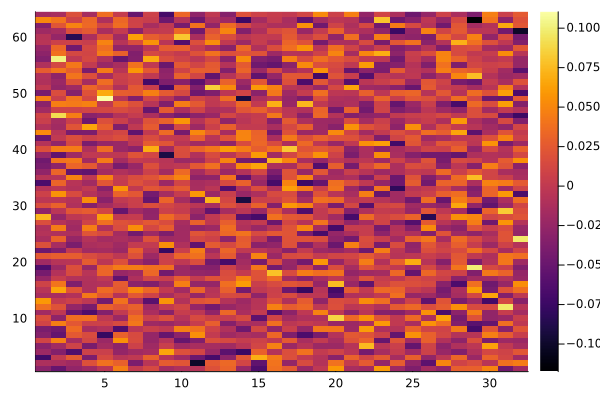

In [25]:
heatmap(aa[1,:,:])

In [26]:
sots = sot |> stack;

In [27]:
scores |> size

(4, 64, 32)

In [28]:
size(sots)

(4, 64, 32, 1001)

In [29]:
cor_realvals(vec(scores), vec(sots[:,:,:,end] |> cdev))

0.9999678f0

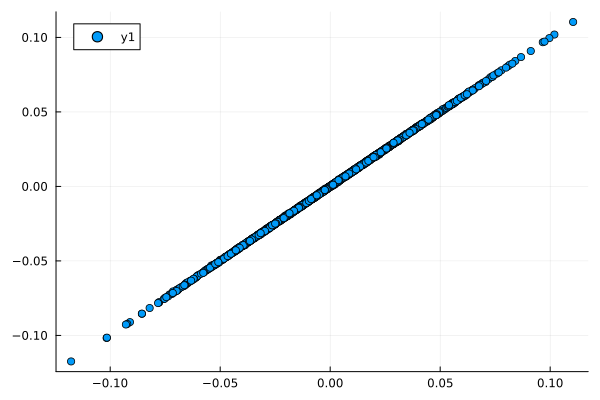

In [30]:
scatter(vec(scores[1,:,:]), vec(sots[1,:,:,end] |> cdev))

In [31]:
#sotc = similarity_outer(qtc, ktc, spk_args=spk_args, tspan=(0.0, 5.0))

In [32]:
#sotsc = sotc |> stack;

In [33]:
#size(sotsc)

In [34]:
#cor_realvals(vec(scores), vec(sotsc[:,:,:,end]) |> cdev)

In [35]:
#scatter(vec(scores[1,:,:]), vec(sotsc[1,:,:,end]))

In [36]:
sol_v = oscillator_bank(vt, tspan = tspan, spk_args = spk_args);

In [38]:
vu = sol_v.u

1001-element Vector{CuArray{ComplexF32, 3, CUDA.DeviceMemory}}:
 [0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im;;; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im;;; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im;;; … ;;; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0

In [40]:
size(vu[1])

(4, 32, 512)

In [ ]:
function score_scale(potential::CuArray{<:Complex,3}, scores::CuArray{<:Real,3})
    @assert size(potential, 1) == size(scores,1) "Batch dimensions of inputs must match"

    scores = permutedims(scores, (2, 3, 1))
    potential = permutedims(potential, (2, 3, 1))
    scaled = batched_mul(scores, potential)
    scaled = permutedims(scaled, (3, 1, 2))
    return scaled
end

score_scale (generic function with 1 method)

In [ ]:
uo = score_scale.(vu, sot)

1001-element Vector{CuArray{ComplexF32, 3, CUDA.DeviceMemory}}:
 [0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im;;; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im;;; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im;;; … ;;; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im; 0.0f0 + 0.0f0im 0.0f0 + 0.0f0im … 0.0f0 + 0.0f0im 0

In [ ]:
uoc = uo |> cdev;

In [ ]:
import .PhasorNetworks: find_spikes_rf

In [ ]:
potential_to_time

potential_to_time (generic function with 2 methods)

In [ ]:
import .PhasorNetworks: generate_cycles

In [ ]:
import .PhasorNetworks: solution_to_train, on_gpu, spiking_offset

In [ ]:
function solution_to_train(sol::Union{ODESolution,Function}, tspan::Tuple{<:Real, <:Real}; spk_args::SpikingArgs, offset::Real)
    #determine the ending time of each cycle
    cycles = generate_cycles(tspan, spk_args, offset)

    #sample the potential at the end of each cycle
    u = solution_to_potential(sol, cycles)
    train = solution_to_train(u, spk_args=spk_args, offset=offset)
    return train
end

function solution_to_train(u::AbstractVector{<:AbstractArray}, t::Vector{<:Real}, tspan::Tuple{<:Real, <:Real}; spk_args::SpikingArgs, offset::Real)
    #determine the ending time of each cycle
    cycles = generate_cycles(tspan, spk_args, offset)
    inds = [argmin(abs.(t .- t_c)) for t_c in cycles]

    #sample the potential at the end of each cycle
    u = u[inds] |> stack
    train = solution_to_train(u, spk_args=spk_args, offset=offset)
    return train
end

function solution_to_train(u::AbstractArray{<:Complex}; spk_args::SpikingArgs, offset::Real)
    #determine the ending time of each cycle
    cycles = generate_cycles(tspan, spk_args, offset)
    
    spiking = abs.(u) .> spk_args.threshold
    
    #convert the phase represented by that potential to a spike time
    tms = potential_to_time(u, cycles, spk_args = spk_args)
    
    if on_gpu(tms)
        gpu = true
        spiking = spiking |> cdev
        tms = tms |> cdev
    else
        gpu = false
    end

    #return only the times where the neuron is spiking
    cut_index = i -> CartesianIndex(Tuple(i)[1:end-1])
    inds = findall(spiking)
    tms = tms[inds]
    inds = cut_index.(inds)
    train = SpikeTrain(inds, tms, size(u)[1:end-1], offset + spiking_offset(spk_args))

    if gpu
        train = SpikeTrainGPU(train)
    end

    return train
end

solution_to_train (generic function with 3 methods)

In [ ]:
typeof(uoc)

Vector{Array{ComplexF32, 3}} (alias for Array{Array{Complex{Float32}, 3}, 1})

In [ ]:
sto = solution_to_train(uoc, sol_v.t |> cdev, (0.0, 10.0), spk_args=spk_args, offset=0.0f0)

Spike Train: (4, 64, 512) with 1119534 spikes.

In [ ]:
# TODO - check corr on cpu.
# TODO - check failing tests